# 03. EDA — 무엇이 연봉을 설명하는가

모델을 돌리기 전에 데이터가 어떤 모양인지 본다.
여기서 정한 두 가지가 04의 설계를 결정한다.

1. 타깃을 **로그로 변환할 것인가**
2. 나이를 **1차로 넣을 것인가 2차항까지 넣을 것인가**

## 0. 환경 설정

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA = ROOT / "data"
CHARTS = ROOT / "output" / "charts" / "notebook"
CHARTS.mkdir(parents=True, exist_ok=True)

# 순서 주의: seaborn의 set_style이 font.family를 sans-serif로 되돌린다.
# 폰트를 먼저 잡고 스타일을 나중에 걸면 한글이 전부 네모로 깨진다.
sns.set_style("whitegrid")

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    from matplotlib import font_manager
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"):
        if candidate in installed:
            plt.rcParams["font.family"] = candidate
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    else:
        print("경고: 한글 폰트를 못 찾았다. 라벨이 네모로 나올 수 있다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("루트:", ROOT)
print("폰트:", plt.rcParams["font.family"])

루트: /Users/tina/Project/SalaryCast_AI
폰트: ['NanumGothic']


In [2]:
hitters = pd.read_csv(DATA / "hitter_training_v10.csv")
pitchers = pd.read_csv(DATA / "pitcher_training_v10.csv")
print(f"타자 {len(hitters)}명 · 투수 {len(pitchers)}명")

타자 136명 · 투수 72명


## 1. 타깃 분포와 로그 변환

01에서 본 대로 연봉은 오른쪽으로 길게 늘어져 있다.
이대로 회귀를 돌리면 소수의 대형 계약이 손실을 지배해서,
모델이 **중간 구간을 대충 맞히고 큰 값에만 매달린다.**
`log1p`로 눌러서 학습하고, 평가할 때 `expm1`로 되돌린다.

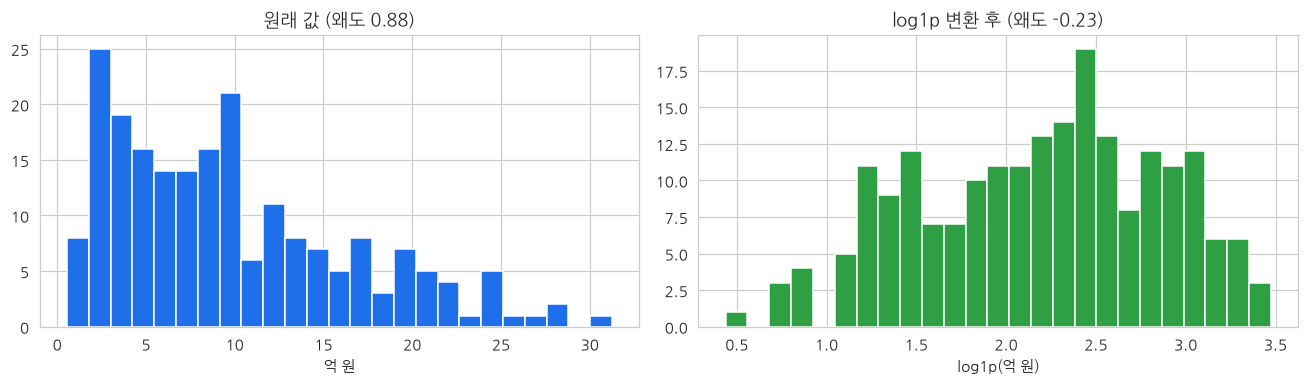

왜도가 0에 가까울수록 좌우 대칭이다.
주의: 로그 공간의 R²는 실제 오차 감각과 다르다. 평가는 억 원으로 되돌려서 한다.


In [3]:
salary = pd.concat([hitters["annual_avg_salary"], pitchers["annual_avg_salary"]])
logged = np.log1p(salary)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(salary, bins=25, color="#1f6feb", edgecolor="white")
axes[0].set_title(f"원래 값 (왜도 {salary.skew():.2f})"); axes[0].set_xlabel("억 원")
axes[1].hist(logged, bins=25, color="#2ea043", edgecolor="white")
axes[1].set_title(f"log1p 변환 후 (왜도 {logged.skew():.2f})"); axes[1].set_xlabel("log1p(억 원)")
plt.tight_layout()
plt.savefig(CHARTS / "03_target_log.png", bbox_inches="tight")
plt.show()

print("왜도가 0에 가까울수록 좌우 대칭이다.")
print("주의: 로그 공간의 R²는 실제 오차 감각과 다르다. 평가는 억 원으로 되돌려서 한다.")

## 2. 무엇이 연봉과 같이 움직이는가

상관계수는 인과가 아니라 **같이 움직이는 정도**다.
그래도 어떤 지표를 봐야 하는지 방향은 잡아준다.

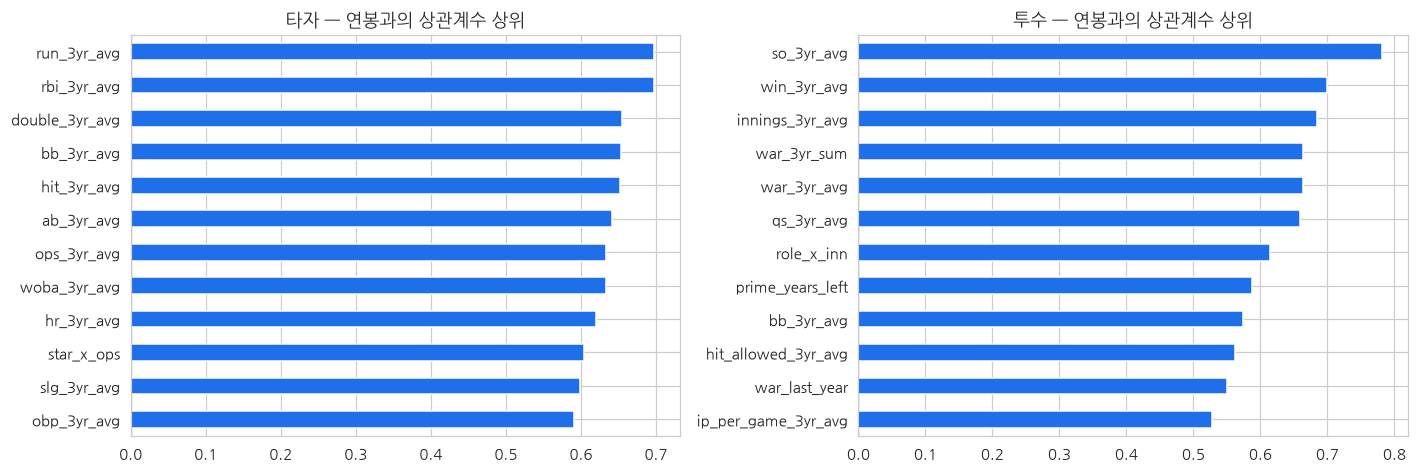

In [4]:
def top_corr(frame, k=12):
    numeric = frame.select_dtypes("number")
    corr = numeric.corr()["annual_avg_salary"].drop("annual_avg_salary")
    return corr.reindex(corr.abs().sort_values(ascending=False).index).head(k)

h_top = top_corr(hitters)
p_top = top_corr(pitchers)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, series, title in [(axes[0], h_top, "타자"), (axes[1], p_top, "투수")]:
    colors = ["#1f6feb" if v > 0 else "#e05c5c" for v in series]
    series.plot(kind="barh", ax=ax, color=colors)
    ax.invert_yaxis()
    ax.axvline(0, color="#888", lw=0.8)
    ax.set_title(f"{title} — 연봉과의 상관계수 상위")
plt.tight_layout()
plt.savefig(CHARTS / "03_correlation.png", bbox_inches="tight")
plt.show()

## 3. WAR과 연봉

WAR(대체 선수 대비 승리 기여)은 타자·투수를 하나의 잣대로 비교할 수 있는 지표다.
3년 합계를 쓰는 이유는 한 시즌의 운을 덜어내기 위해서다.

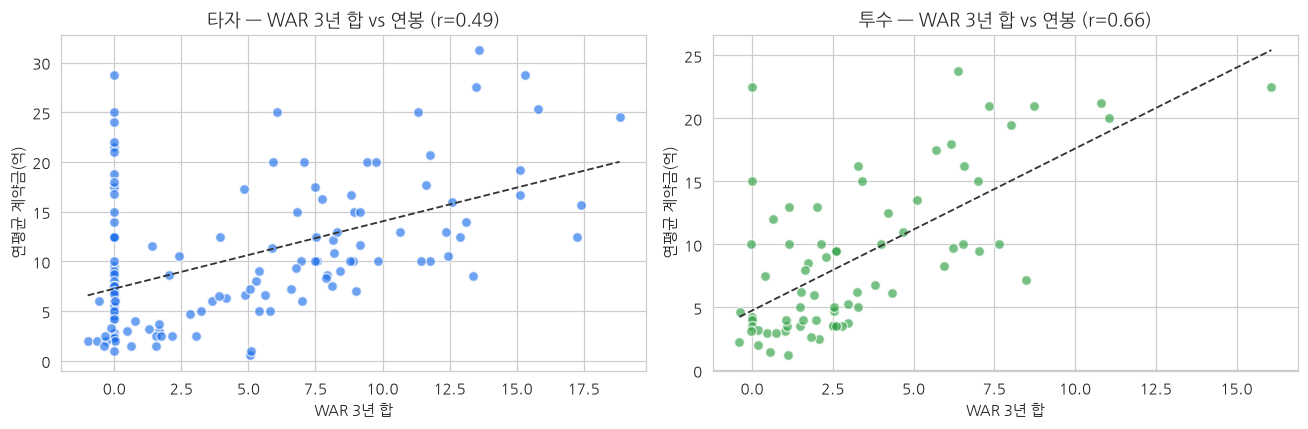

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, frame, title, color in [
        (axes[0], hitters, "타자", "#1f6feb"), (axes[1], pitchers, "투수", "#2ea043")]:
    ax.scatter(frame["war_3yr_sum"], frame["annual_avg_salary"],
               alpha=0.65, s=42, color=color, edgecolor="white")
    fit = np.polyfit(frame["war_3yr_sum"], frame["annual_avg_salary"], 1)
    xs = np.linspace(frame["war_3yr_sum"].min(), frame["war_3yr_sum"].max(), 50)
    ax.plot(xs, np.polyval(fit, xs), color="#333", ls="--", lw=1.2)
    r = frame["war_3yr_sum"].corr(frame["annual_avg_salary"])
    ax.set_title(f"{title} — WAR 3년 합 vs 연봉 (r={r:.2f})")
    ax.set_xlabel("WAR 3년 합"); ax.set_ylabel("연평균 계약금(억)")
plt.tight_layout()
plt.savefig(CHARTS / "03_war_salary.png", bbox_inches="tight")
plt.show()

## 4. 나이 — 직선이 아니다

나이는 연봉과 단순 반비례가 아니다.
너무 어리면 FA 자격 자체를 못 얻고, 30대 초반에 정점을 찍은 뒤 떨어진다.
**곡선**이므로 1차항만 넣으면 이 모양을 못 잡는다.
그래서 `age_squared`(나이²)를 같이 넣는다 — 다항회귀와 같은 발상이다.

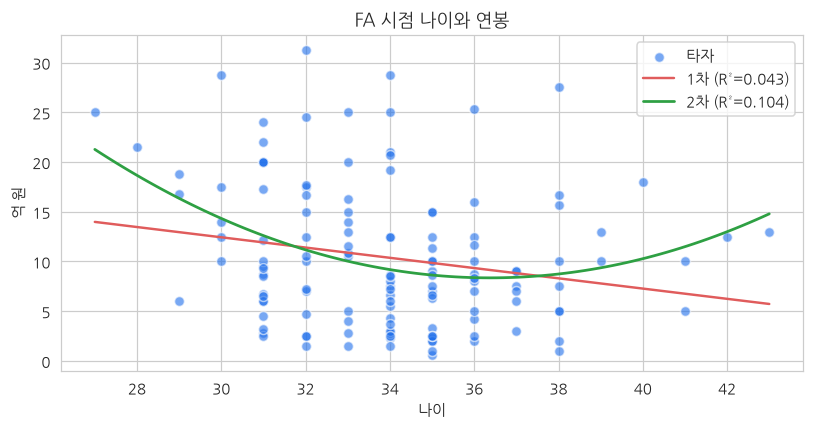

2차항을 넣으면 설명력이 올라간다 -> age_squared를 피처로 유지한다.


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

ages = hitters["age_at_fa"].values.reshape(-1, 1)
target = hitters["annual_avg_salary"].values

linear = LinearRegression().fit(ages, target)
poly = PolynomialFeatures(degree=2, include_bias=False)
ages_poly = poly.fit_transform(ages)
quadratic = LinearRegression().fit(ages_poly, target)

grid = np.linspace(ages.min(), ages.max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(ages, target, alpha=0.6, s=42, color="#1f6feb", edgecolor="white", label="타자")
ax.plot(grid, linear.predict(grid), color="#e05c5c", lw=1.6,
        label=f"1차 (R²={linear.score(ages, target):.3f})")
ax.plot(grid, quadratic.predict(poly.transform(grid)), color="#2ea043", lw=1.8,
        label=f"2차 (R²={quadratic.score(ages_poly, target):.3f})")
ax.set_title("FA 시점 나이와 연봉"); ax.set_xlabel("나이"); ax.set_ylabel("억 원")
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS / "03_age_curve.png", bbox_inches="tight")
plt.show()

print("2차항을 넣으면 설명력이 올라간다 -> age_squared를 피처로 유지한다.")

## 5. 포지션별 차이

같은 성적이라도 포지션에 따라 시장 가치가 다르다.
수비 부담이 큰 포수·유격수는 공격 지표가 조금 낮아도 값이 붙는다.

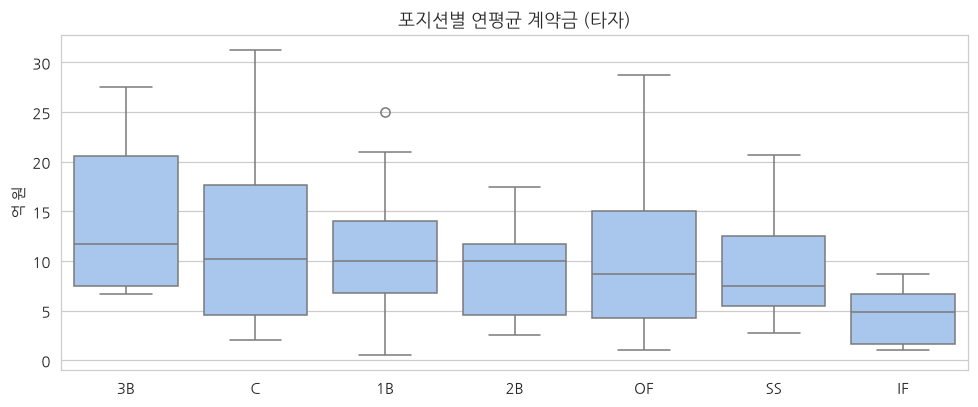

,count,median,max
position,,,
3B,14,11.74,27.50
C,20,10.25,31.25
1B,15,10.00,25.00
2B,13,10.00,17.50
OF,49,8.67,28.75
SS,15,7.50,20.67
IF,10,4.84,8.67


In [7]:
order = (hitters.groupby("position")["annual_avg_salary"]
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.boxplot(data=hitters, x="position", y="annual_avg_salary",
            order=order, ax=ax, color="#9ec5f7")
ax.set_title("포지션별 연평균 계약금 (타자)")
ax.set_xlabel(""); ax.set_ylabel("억 원")
plt.tight_layout()
plt.savefig(CHARTS / "03_position.png", bbox_inches="tight")
plt.show()

display(hitters.groupby("position")["annual_avg_salary"]
        .agg(["count", "median", "max"]).round(2).sort_values("median", ascending=False))

## 정리 — 04로 넘기는 결정

1. **타깃은 `log1p`로 변환해 학습하고, 평가는 `expm1`로 되돌려 억 원으로** 한다
2. **`age_squared`를 유지**한다 — 나이와 연봉은 곡선 관계다
3. WAR 3년 합이 타자·투수 모두에서 강한 단일 지표다
4. 포지션·투수 역할은 범주 피처로 반영한다

다음: `04_model_train.ipynb`